# Visualisierung Eniac

## Bibliotheken importieren + Daten laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
sns.set(style="whitegrid", font_scale=1.1)
from google.colab import files

In [2]:
url = "https://drive.google.com/file/d/1hi3IBFZAjiFrdtW7bbx4zsWSMM1Bljzz/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products = pd.read_csv(path)

url = "https://drive.google.com/file/d/1MNhAJ_BR53ShgBlGvXaGoQBpRdUIRxcT/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders = pd.read_csv(path)

url = "https://drive.google.com/file/d/1VfiHSkHovYavheYkX-up4oTYlgcM32QJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines = pd.read_csv(path)

url = "https://drive.google.com/file/d/1HIN9kIXFSzIq4QNjfFQ8_S2gLlZMgrRE/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)

## Fehlende Kategorien auffüllen

In [3]:
products['category'] = products['category'].fillna('Unbekannt')

## Umsatz pro Kategorie (Balkendiagramm) – beantwortet Geschäftsfrage 4

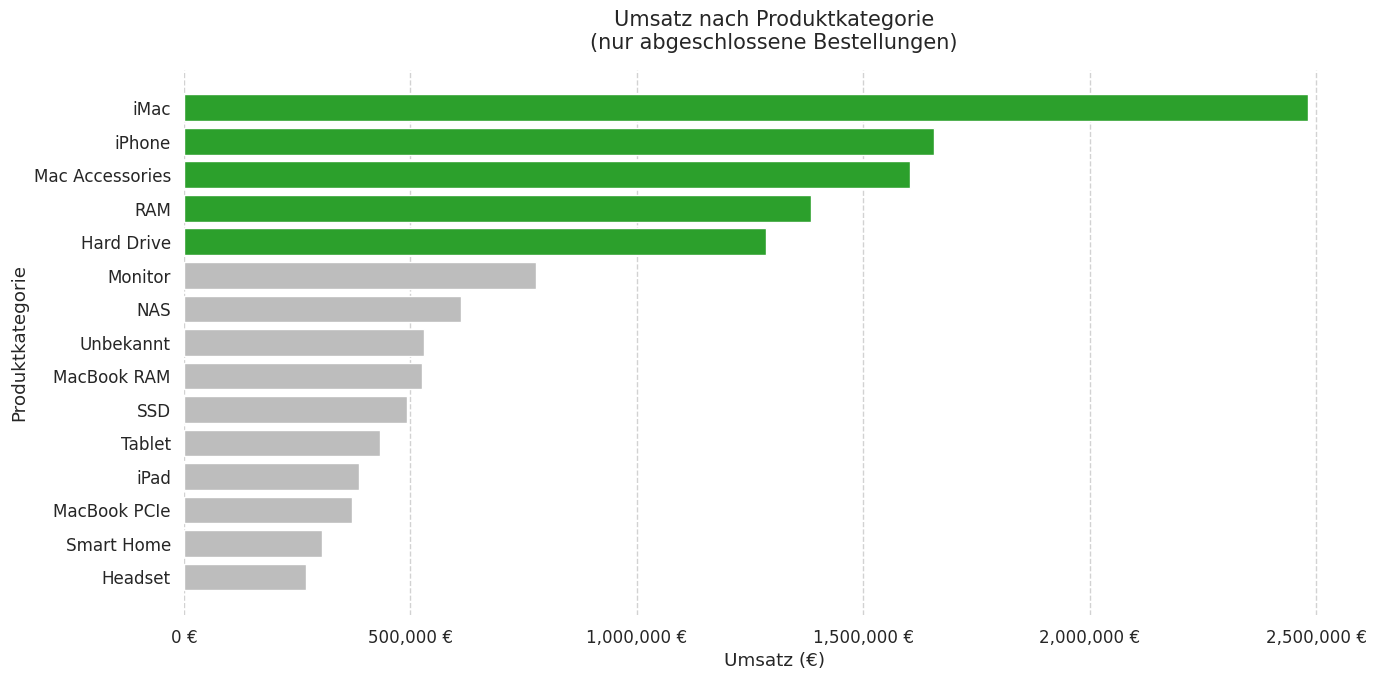

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# Daten zusammenführen
merged = orderlines.merge(
    products[['sku', 'category']],
    on='sku',
    how='left'
)

# Fehlende Kategorien ersetzen
merged['category'] = merged['category'].fillna('Unbekannt')

# Umsatz berechnen
merged['revenue'] = (
    merged['unit_price'] *
    merged['product_quantity']
)

# Bestellstatus hinzufügen
merged = merged.merge(
    orders[['order_id', 'state']],
    left_on='id_order',
    right_on='order_id',
    how='inner'
)

# Nur abgeschlossene Bestellungen berücksichtigen
completed = merged[
    merged['state'] == 'Completed'
]

# Umsatz je Kategorie berechnen
revenue_per_category = (
    completed
    .groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

# Die fünf größten Balken grün,
# die übrigen Balken grau
colors = [
    '#2ca02c' if i < 5 else '#bdbdbd'
    for i in range(len(revenue_per_category))
]

# Diagramm erstellen
fig, ax = plt.subplots(figsize=(14, 7))

ax.barh(
    revenue_per_category.index,
    revenue_per_category.values,
    color=colors,
    zorder=3
)

# Größter Umsatz oben
ax.invert_yaxis()

# Achsenbeschriftungen
ax.set_xlabel('Umsatz (€)')
ax.set_ylabel('Produktkategorie')

ax.set_title(
    'Umsatz nach Produktkategorie\n'
    '(nur abgeschlossene Bestellungen)',
    fontsize=15,
    pad=15
)

# Nur vertikale Gitterlinien anzeigen
# Sie verlaufen von oben nach unten
ax.grid(
    axis='x',
    linestyle='--',
    color='gray',
    alpha=0.35,
    zorder=0
)

# Horizontale Gitterlinien entfernen
ax.grid(
    axis='y',
    visible=False
)

ax.set_axisbelow(True)

# Wissenschaftliche Schreibweise wie 1e6 verhindern
ax.xaxis.set_major_formatter(
    StrMethodFormatter('{x:,.0f} €')
)

# Offset-Text wie 1e6/le6 vollständig entfernen
ax.xaxis.get_offset_text().set_visible(False)

# Legenden vollständig entfernen
if ax.get_legend() is not None:
    ax.get_legend().remove()

fig.legends.clear()

# Überflüssige Rahmenlinien entfernen
sns.despine(
    ax=ax,
    left=True,
    bottom=True
)

plt.tight_layout()

# Diagramm speichern
plt.savefig(
    'umsatz_produktkategorie.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Download in Google Colab
from google.colab import files

files.download(
    'umsatz_produktkategorie.png'
)

## Katalogpreis vs. durchschnittlicher Rabattpro Kategorie

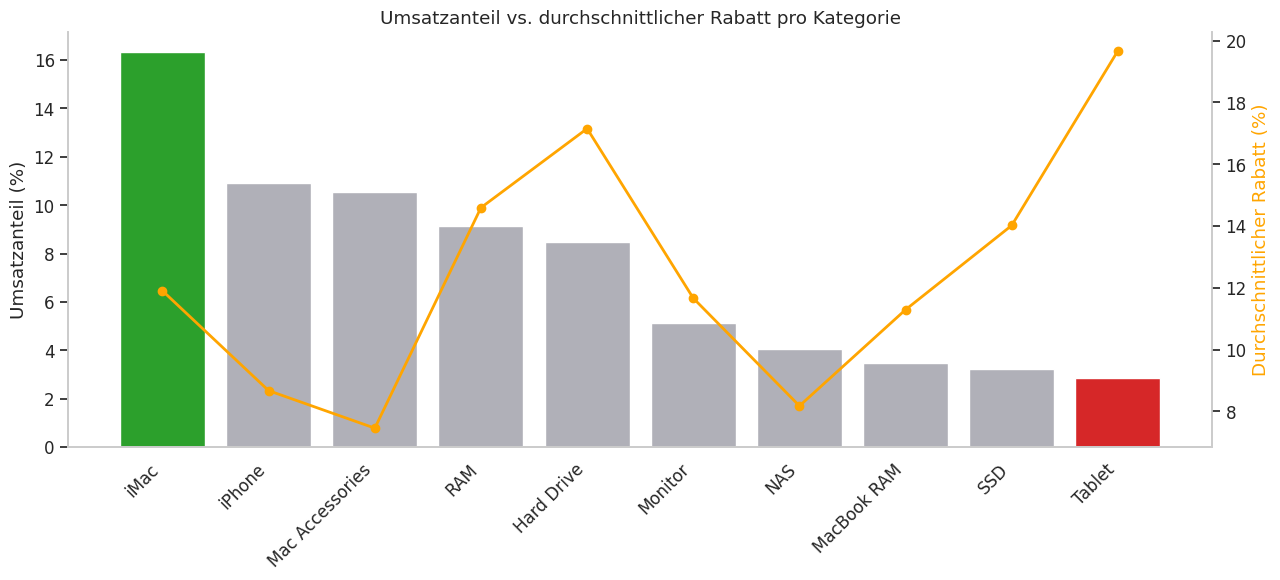

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
merged = orderlines.merge(products[['sku','category','price']], on='sku', how='left')
merged = merged.merge(orders[['order_id','state']], left_on='id_order', right_on='order_id')
completed = merged[merged['state']=='Completed'].copy()
completed['revenue'] = completed['unit_price'] * completed['product_quantity']
completed['discount_pct'] = (completed['price'] - completed['unit_price']) / completed['price'] * 100
completed = completed[completed['price']>0]

# WICHTIG: head(10) statt head(8), damit Tablet mit drin ist
summary = completed.groupby('category').agg(
    revenue=('revenue','sum'),
    avg_discount=('discount_pct','mean')
).sort_values('revenue', ascending=False).head(10)
summary['revenue_pct'] = summary['revenue']/completed['revenue'].sum()*100

# Farben: iMac und Tablet hervorheben, Rest neutral grau
bar_colors = []
for cat in summary.index:
    if cat == 'iMac':
        bar_colors.append('#2ca02c')   # grün, das "gute" Beispiel
    elif cat == 'Tablet':
        bar_colors.append('#d62728')   # rot, das "schlechte" Beispiel
    else:
        bar_colors.append('#b0b0b8')   # neutral grau für alle anderen

fig, ax1 = plt.subplots(figsize=(13,6))
x = range(len(summary))
ax1.bar(x, summary['revenue_pct'], color=bar_colors)
ax1.set_ylabel('Umsatzanteil (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(summary.index, rotation=45, ha='right')
ax1.grid(False)  # Gitter im Hintergrund entfernen

ax2 = ax1.twinx()
ax2.plot(x, summary['avg_discount'], color='orange', marker='o', linewidth=2)
ax2.set_ylabel('Durchschnittlicher Rabatt (%)', color='orange')
ax2.grid(False)  # auch hier Gitter entfernen

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.title('Umsatzanteil vs. durchschnittlicher Rabatt pro Kategorie')
plt.tight_layout()
plt.savefig('umsatz_vs_rabatt.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('umsatz_vs_rabatt.png')

In [7]:
# --------------------------------------------------
# 1. Datum korrekt umwandeln
# --------------------------------------------------

orders['created_date'] = pd.to_datetime(
    orders['created_date'],
    errors='coerce'
)

# Ungültige Datumswerte entfernen
orders_clean = orders.dropna(
    subset=['created_date']
).copy()

# --------------------------------------------------
# 2. Tagesumsatz berechnen
# --------------------------------------------------

daily_revenue = (
    orders_clean[
        orders_clean['state'] == 'Completed'
    ]
    .assign(
        date=lambda df: df['created_date'].dt.normalize()
    )
    .groupby('date', as_index=False)['total_paid']
    .sum()
    .rename(
        columns={'total_paid': 'revenue'}
    )
    .sort_values('date')
)

# Kontrolle
display(daily_revenue.head())

,date,revenue
0,2017-01-01,36423.45
1,2017-01-02,56740.52
2,2017-01-03,59321.74
3,2017-01-04,35466.70
4,2017-01-05,25435.87


## Saisonalität – Umsatz über Zeit mit markierten Terminen

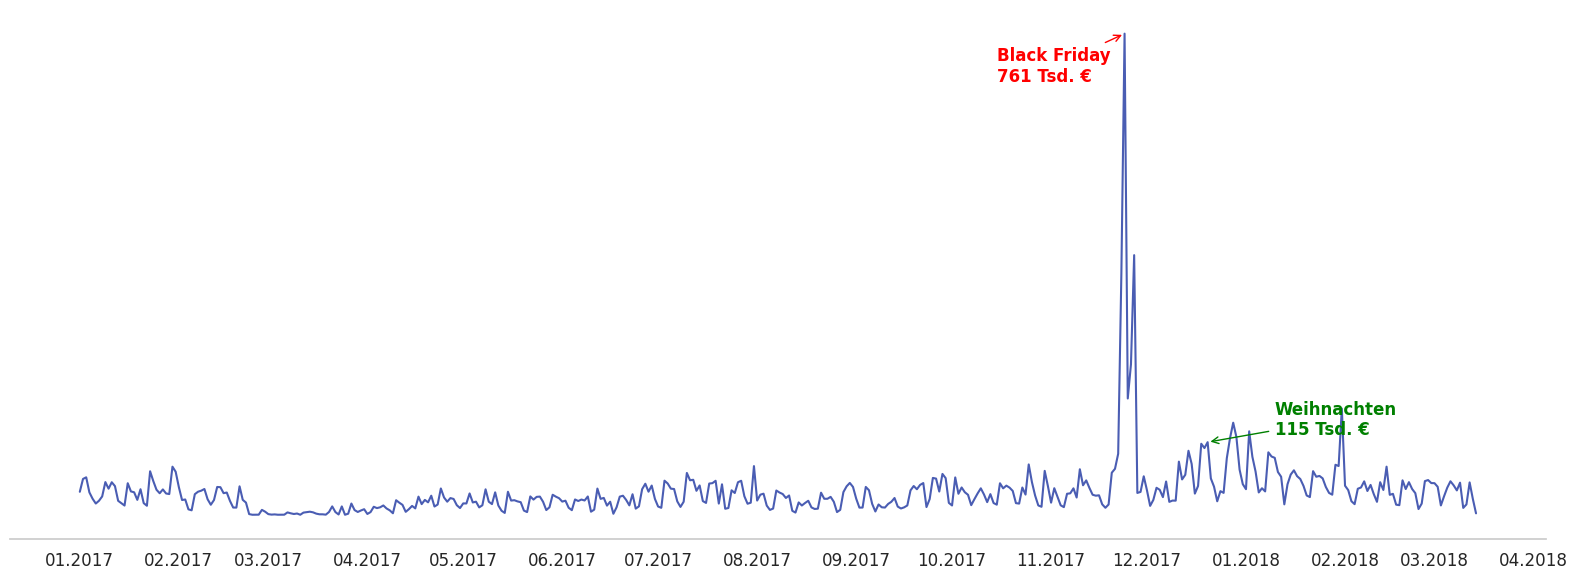

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# --------------------------------------------------
# 3. Diagramm erstellen
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    daily_revenue['date'],
    daily_revenue['revenue'],
    color='#4a5db3',
    linewidth=1.5
)

# Keine Gitterlinien
ax.grid(False)

# Y-Achsenwerte ausblenden
ax.set_yticks([])

# Rahmenlinien entfernen
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# X-Achse formatieren
ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%m.%Y')
)


# --------------------------------------------------
# 4. Black Friday beschriften
# --------------------------------------------------

black_friday = pd.Timestamp('2017-11-24')

bf_data = daily_revenue[
    daily_revenue['date'] == black_friday
]

if not bf_data.empty:
    bf_peak = bf_data['revenue'].iloc[0]

    ax.annotate(
        f'Black Friday\n{bf_peak / 1000:,.0f} Tsd. €',
        xy=(black_friday, bf_peak),
        xytext=(
            pd.Timestamp('2017-10-15'),
            bf_peak * 0.9
        ),
        arrowprops=dict(
            arrowstyle='->',
            color='red'
        ),
        fontsize=12,
        color='red',
        fontweight='bold'
    )

# --------------------------------------------------
# 5. Weihnachtsbereich beschriften
# --------------------------------------------------

christmas_data = daily_revenue[
    (daily_revenue['date'] >= pd.Timestamp('2017-12-15')) &
    (daily_revenue['date'] <= pd.Timestamp('2017-12-25'))
]

if not christmas_data.empty:
    xmas_peak = christmas_data['revenue'].max()

    xmas_peak_date = christmas_data.loc[
        christmas_data['revenue'].idxmax(),
        'date'
    ]

    ax.annotate(
        f'Weihnachten\n{xmas_peak / 1000:,.0f} Tsd. €',
        xy=(xmas_peak_date, xmas_peak),
        xytext=(
            pd.Timestamp('2018-01-10'),
            xmas_peak * 1.1
        ),
        arrowprops=dict(
            arrowstyle='->',
            color='green'
        ),
        fontsize=12,
        color='green',
        fontweight='bold'
    )

# X-Achsenbeschriftung ausblenden
ax.set_xlabel('')

plt.tight_layout()

# --------------------------------------------------
# 6. Speichern und Download
# --------------------------------------------------

plt.savefig(
    'saisonalitaet.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

files.download(
    'saisonalitaet.png'
)